### **1. Introduction**
Raw soil data is often provided in discrete, separate depth layers (ex: 0-5cm, 5-15cm, 15-30cm, etc.). To build a reliable crop recommendation system, these layers must be processed into consolidated root zone features.

* Root Zone Selection: The top 6 inches (15 cm) of soil has the most root activity and fertilizer applications are generally restricted to this depth.
* TAW Calculation: Determine how much water the soil can hold for plants.
* Vertical Integration: Create weighted averages for properties across the selected soil depths.
* Agronomic Classification: Categorize the soil into USDA Texture Classes (ex: Sandy Loam, Clay Loam, etc.) based on the physical proportions of sand, silt, and clay.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")
sns.set_palette("husl")

In [2]:
# Load the spatially clipped Western Province data from notebook 02
df = pd.read_csv("../data/processed/soil_pixels_western.csv")
print(df.shape)
df.head()

(3422, 47)


,lon,lat,bd_0-5cm,bd_15-30cm,bd_30-60cm,bd_5-15cm,bd_60-100cm,cec_0-5cm,cec_15-30cm,cec_30-60cm,...,vmc15_0-5cm,vmc15_15-30cm,vmc15_30-60cm,vmc15_5-15cm,vmc15_60-100cm,vmc33_0-5cm,vmc33_15-30cm,vmc33_30-60cm,vmc33_5-15cm,vmc33_60-100cm
0,80.125184,7.323213,1.557927,1.442331,1.439978,1.415508,1.345131,15.267301,16.852371,15.398573,...,0.136998,0.124837,0.130485,0.133131,0.115818,0.195194,0.176813,0.185719,0.189695,0.158228
1,80.134612,7.323213,1.558571,1.440546,1.438355,1.412790,1.345062,15.265265,16.851543,15.398051,...,0.138358,0.125894,0.130853,0.134477,0.116135,0.197316,0.178222,0.186291,0.191714,0.158815
2,80.002622,7.313786,1.543519,1.542667,1.551212,1.527530,1.348263,15.189331,16.596306,14.792064,...,0.112024,0.105075,0.111875,0.109097,0.105837,0.158121,0.150447,0.156935,0.155038,0.137779
3,80.012050,7.313786,1.543147,1.543052,1.551626,1.527253,1.348302,15.187772,16.595743,14.791530,...,0.113405,0.106234,0.112188,0.110480,0.106229,0.159969,0.151812,0.157299,0.156828,0.138326
4,80.021478,7.313786,1.542923,1.543448,1.552039,1.527009,1.348340,15.186189,16.595175,14.790990,...,0.114780,0.107385,0.112495,0.111856,0.106619,0.161818,0.153168,0.157660,0.158620,0.138870


### **2. Calculating Total Available Water (TAW)** 
The Total Available Water (TAW) represents the amount of water a plant can extract from its root zone. It is the numerical difference between the water content at Field Capacity (the amount of water the soil holds after drainage) and the Wilting Point (the point where plants can no longer pull water from the soil).

TAW is calculated by integrating these values over the top 6 inches of the soil profile using the following formula:
$$TAW = \sum_{i=1}^{n} (\theta_{FC,i} - \theta_{WP,i}) \times T_i$$
$\theta_{FC,i}$ = The water content at field capacity for Layer $i$\
$\theta_{WP,i}$ = The water content at wilting point for Layer $i$\
$T_i$ = The thickness of layer $i$ in mm\
$n$: The total number of layers being integrated

In [3]:
# Define layers and their respective thicknesses
depths = ["0-5cm", "5-15cm"]
thickness_cm = [5, 10]
thickness_mm = [t * 10 for t in thickness_cm]

# Identify columns for field capacity and wilting point
fc_cols = [f"vmc33_{d}" for d in depths]
wp_cols = [f"vmc15_{d}" for d in depths]

taw_layers = []
for i in range(len(depths)):
    # Calculate available water for each layer
    taw = (df[fc_cols[i]] - df[wp_cols[i]]) * thickness_mm[i]
    taw_layers.append(taw)

# Sum the available water across both layers to get the TAW for the profile
df["taw"] = sum(taw_layers)

### **3. Vertical Integration (Weighted Averages)**
To collapse multiple layers into a single representative value, there can be two types of weighting:

* Thickness Weighted Average (For Physical Structure): Used for pH and Bulk Density. It averages values based on the volume of the layer.
$$P_{weighted} = \frac{\sum_{i=1}^{n} (P_i \times T_i)}{\sum_{i=1}^{n} T_i}$$

* Mass Weighted Average (For Concentrations): Used for Organic Carbon, CEC, Clay and Sand. It accounts for the fact that denser soil layers contain more actual soil mass per cm.
$$P_{weighted} = \frac{\sum_{i=1}^{n} (P_i \times BD_i \times T_i)}{\sum_{i=1}^{n} (BD_i \times T_i)}$$

$P_{weighted}$: The final integrated property value for the total root zone\
$P_i$: The value of the soil property in layer $i$\
$T_i$: The thickness of layer $i$\
$BD_i$: The bulk density of layer $i$\
$n$: The total number of layers being integrated

In [4]:
def thickness_weighted_avg(df, prop, depths, thickness_cm):
    # Calculate average soil property based on the thickness of each layer
    prop_cols = [f"{prop}_{d}" for d in depths]
    prop_values = np.vstack([df[c] for c in prop_cols])
    return np.average(prop_values, axis=0, weights=thickness_cm)

In [5]:
def mass_weighted_avg(df, prop, bd, depths, thickness_cm):
    # Calculate average soil property based on both thickness and soil mass (bulk density)
    prop_cols = [f"{prop}_{d}" for d in depths]
    bd_cols = [f"{bd}_{d}" for d in depths]

    prop_values = np.vstack([df[c] for c in prop_cols])
    bd_values = np.vstack([df[c] for c in bd_cols])

    # Weights = (density * thickness)
    weights = bd_values * np.array(thickness_cm)[:, None]

    return np.sum(prop_values * weights, axis=0) / np.sum(weights, axis=0)

In [6]:
# Apply thickness weighted averaging
df["ph"] = thickness_weighted_avg(df, "ph", depths, thickness_cm)
df["bulk_density"] = thickness_weighted_avg(df, "bd", depths, thickness_cm)

# Apply mass weighted averaging
df["organic_carbon"] = mass_weighted_avg(df, "oc", "bd", depths, thickness_cm)
df["cec"] = mass_weighted_avg(df, "cec", "bd", depths, thickness_cm)
df["clay_pct"] = mass_weighted_avg(df, "clay", "bd", depths, thickness_cm)
df["sand_pct"] = mass_weighted_avg(df, "sand", "bd", depths, thickness_cm)

### **4. Creating Agronomic Texture Classes**
The USDA Soil Texture Triangle criteria is used to classify each pixel based on its sand, clay, and silt proportions.

![alt text](usda-textural-classes-of-soils.png)

In [7]:
def classify_usda_texture(row):
    sand = row["sand_pct"]
    clay = row["clay_pct"]
    silt = 100 - sand - clay

    # Coarse texture
    if sand >= 86 and clay <= 10 and silt <= 14:
        return "Sand"

    if 70 <= sand < 86 and clay <= 15 and silt <= 30:
        return "Loamy sand"

    # Moderately coarse texture
    if 50 <= sand < 70 and clay <= 20 and silt <= 50:
        return "Sandy loam"

    # Medium texture
    if sand <= 20 and clay <= 12 and silt >= 80:
        return "Silt"

    if clay <= 27 and 50 <= silt < 80:
        return "Silt loam"

    if 23 <= sand <= 52 and 7 <= clay <= 27 and 28 <= silt <= 50:
        return "Loam"

    # Moderately fine texture
    if 45 <= sand <= 80 and 20 <= clay < 35 and silt <= 28:
        return "Sandy clay loam"

    if 20 <= sand < 45 and 27 <= clay < 40 and 15 <= silt <= 52:
        return "Clay loam"

    if sand <= 20 and 27 <= clay < 40 and silt >= 40:
        return "Silty clay loam"

    # Fine texture
    if sand >= 45 and clay >= 35 and silt <= 20:
        return "Sandy clay"

    if sand <= 20 and clay >= 40 and silt >= 40:
        return "Silty clay"

    if clay >= 40:
        return "Clay"

    return "Loam"

df["texture_class"] = df.apply(classify_usda_texture, axis=1)

### **5. Statistical and Distribution Analysis**
The range of engineered features are verified to ensure they are within realistic bounds for the Western Province.

In [8]:
df[[
    "taw", "organic_carbon", "cec", "ph", "bulk_density"
]].describe().round(2)

,taw,organic_carbon,cec,ph,bulk_density
count,3422.00,3422.00,3422.00,3422.00,3422.00
mean,7.38,3.51,14.83,4.95,1.26
std,0.81,0.55,4.21,0.25,0.12
min,5.88,2.22,7.82,4.57,1.06
25%,6.70,3.15,9.67,4.76,1.17
50%,7.41,3.26,16.67,4.88,1.23
75%,7.85,3.93,18.34,5.12,1.32
max,9.50,4.93,21.60,5.59,1.53


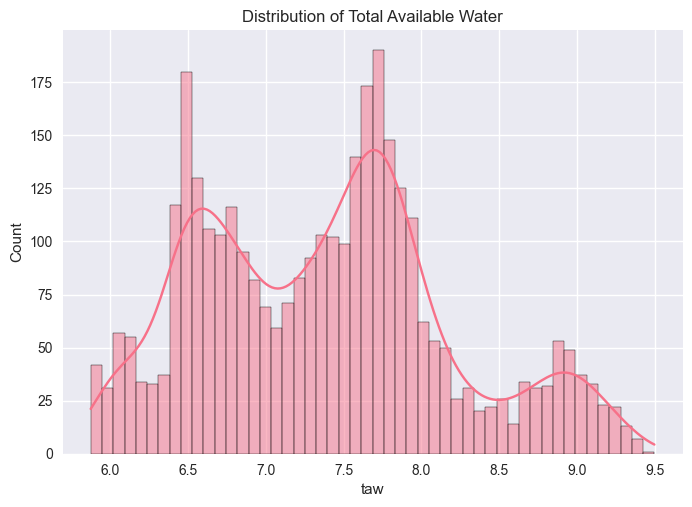

In [9]:
sns.histplot(df["taw"], bins=50, kde=True)
plt.title("Distribution of Total Available Water")
plt.show()

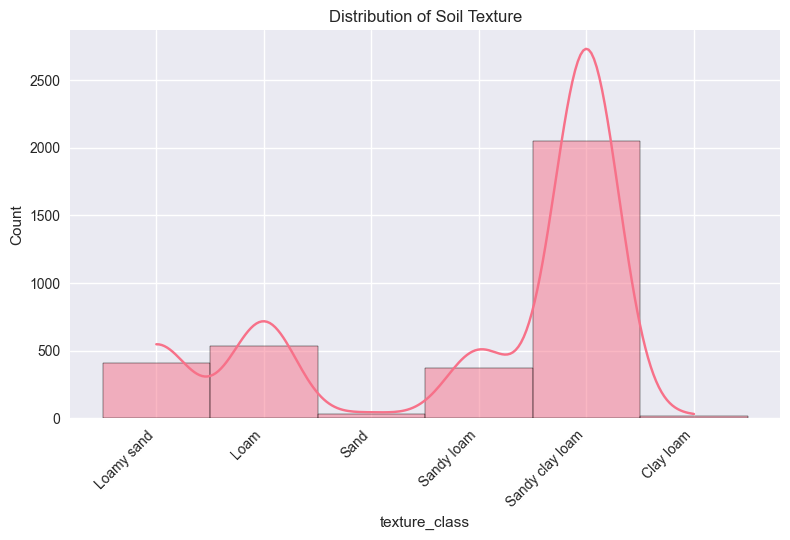

In [10]:
sns.histplot(df["texture_class"], bins=50, kde=True)
plt.xticks(rotation=45, ha='right')
plt.title("Distribution of Soil Texture")
plt.tight_layout()
plt.show()

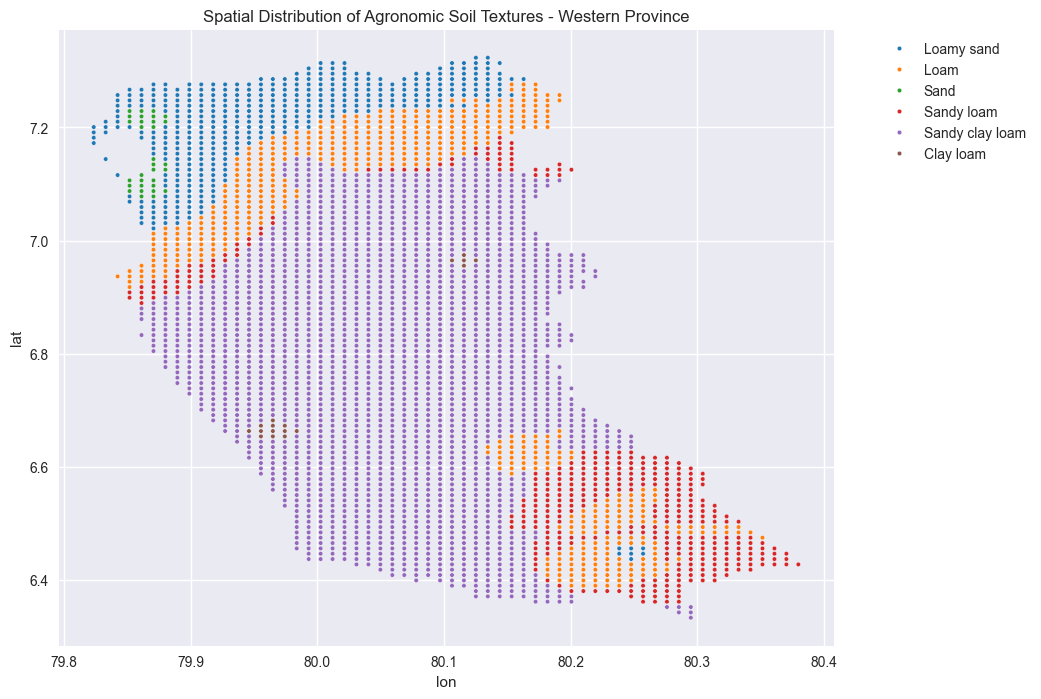

In [11]:
plt.figure(figsize=(10, 8))
sns.scatterplot(data=df, x="lon", y="lat", hue="texture_class", palette="tab10", s=10)
plt.title("Spatial Distribution of Agronomic Soil Textures - Western Province")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

### **6. Detecting Multicollinearity**
Before applying unsupervised learning techniques, it is important to examine the relationships between soil features. Highly correlated variables may contain redundant information and can distort distance based clustering algorithms. Therefore, a correlation analysis is performed to identify multicollinearity and guide feature selection.

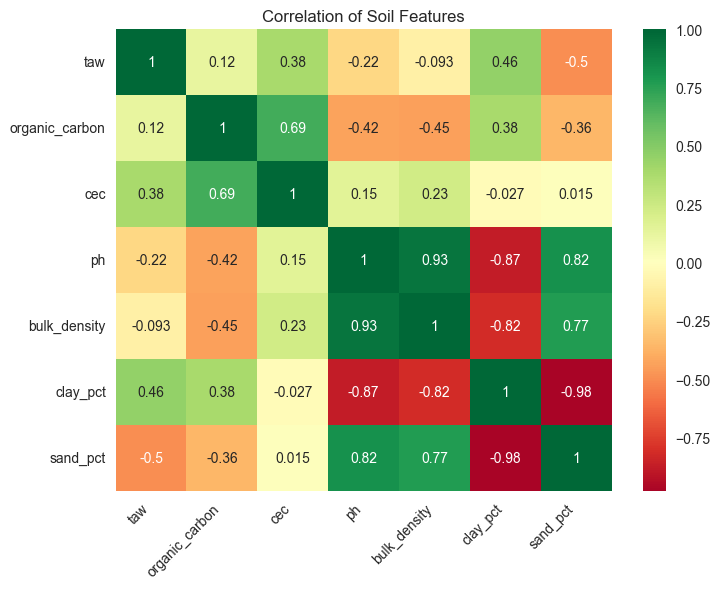

In [12]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    df[["taw","organic_carbon","cec","ph","bulk_density", "clay_pct", "sand_pct"]].corr(),
    annot=True, cmap="RdYlGn", center=0
)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.title("Correlation of Soil Features")
plt.show()

### **7. Results of Multicollinearity Analysis and Feature Selection**

The correlation analysis revealed several near perfect relationships among soil variables, indicating severe multicollinearity. To ensure a stable, unbiased, and interpretable clustering process, the feature set was refined by removing redundant variables.

Although bulk density and clay content exhibit distinct secondary correlations with other soil properties, their extremely high correlations with pH ($r \approx 0.93$) and sand percentage ($r \approx −0.98$) respectively indicate substantial redundancy. In distance based unsupervised learning, retaining highly collinear variables can distort cluster geometry by disproportionately weighting specific soil dimensions. Therefore, pH and sand percentage were retained as more agronomically interpretable representatives, while bulk density and clay content were excluded to preserve feature independence and clustering integrity.

In [13]:
CLUSTER_FEATURES = [
    "taw",
    "organic_carbon",
    "cec",
    "ph",
    "sand_pct"
]

In [14]:
output_path = "../outputs/soil_features_final.csv"
df_final = df[["lon", "lat"] + CLUSTER_FEATURES + ["texture_class"]]
df_final.to_csv(output_path, index=False)

print("Saved:", output_path)

Saved: ../outputs/soil_features_final.csv


In [15]:
most_active_root_depth = sum(thickness_mm)
df["awc"] = df["taw"] / most_active_root_depth

soil_db_output_path = "../outputs/soil_features_for_db.csv"
df_for_db = df[["lon", "lat"] + CLUSTER_FEATURES + ["bulk_density"] + ["awc"] + ["texture_class"]]
df_for_db.to_csv(soil_db_output_path, index=False)

print("Saved:", soil_db_output_path)

Saved: ../outputs/soil_features_for_db.csv
